# 03 CNN+BiLSTM+Attention 情感模型训练

In [1]:
import os
import math
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/Emotion-perception-driven-speech-recognition-system


In [2]:
import sys
import time
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset, Subset
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config
from utils.losses import FocalLoss
from utils.split_utils import speaker_group_split
from preprocessing.feature_extract import EmotionDataset, AudioAugmentation
from models.emotion_cnn_bilstm import EmotionRecognizer

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

设备: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. 准备数据

In [3]:
from preprocessing.feature_extract import EmotionDataset, AudioAugmentation

"""论文演示目的：
构建用于训练的 Dataset 列表，并展示"跨数据集拼接训练"的做法。

这里的 EmotionDataset 读取的是 preprocessing/feature_extract.py 输出的 .npy 特征文件：
    data/features/<subset>/{mel,mfcc}/<label>/*.npy

注意：该 Dataset 的一个隐含约束是 mel/ 目录下第一层必须是情感标签目录名。
"""

features_root = cfg['paths']['features']
feature_type = 'mel'

# 训练阶段使用数据增强（SpecAugment + 噪声）；验证/测试不增强
train_transform = AudioAugmentation(
    time_mask_max=20,
    freq_mask_max=10,
    noise_std=0.01,
)

train_datasets = []
valtest_datasets = []

# 本系统当前支持的数据子集（可按需要扩展）
for subset in ('ravdess', 'casia', 'tess', 'esd', 'emodb', 'iemocap'):
    subset_features = os.path.join(features_root, subset)
    if not os.path.isdir(subset_features):
        print(f'[跳过] 特征目录不存在: {subset_features}')
        continue

    # 训练集（增强）
    train_datasets.append(
        EmotionDataset(subset_features, feature_type=feature_type, transform=train_transform)
    )
    # 验证/测试（不增强）
    valtest_datasets.append(
        EmotionDataset(subset_features, feature_type=feature_type, transform=None)
    )

print(f'训练子集数量: {len(train_datasets)} | 验证/测试子集数量: {len(valtest_datasets)}')


EmotionDataset: 加载 1440 个样本 (feature_type=mel)
EmotionDataset: 加载 1440 个样本 (feature_type=mel)
EmotionDataset: 加载 1200 个样本 (feature_type=mel)
EmotionDataset: 加载 1200 个样本 (feature_type=mel)
EmotionDataset: 加载 2600 个样本 (feature_type=mel)
EmotionDataset: 加载 2600 个样本 (feature_type=mel)
EmotionDataset: 加载 34997 个样本 (feature_type=mel)
EmotionDataset: 加载 34997 个样本 (feature_type=mel)
EmotionDataset: 加载 535 个样本 (feature_type=mel)
EmotionDataset: 加载 535 个样本 (feature_type=mel)
EmotionDataset: 加载 7415 个样本 (feature_type=mel)
EmotionDataset: 加载 7415 个样本 (feature_type=mel)
训练子集数量: 6 | 验证/测试子集数量: 6


In [4]:
# 将多个数据子集合并，并构建 train/val/test 划分与 DataLoader
full_train = ConcatDataset(train_datasets)       # 训练用（含增强）
full_plain = ConcatDataset(valtest_datasets)     # 验证/测试用（不增强）

if len(full_train) == 0:
    raise RuntimeError('没有可用训练数据，请先完成特征提取并检查 data/features/<subset>/ 目录。')
if len(full_train) != len(full_plain):
    raise RuntimeError('增强集与非增强集样本数不一致，请检查数据准备流程。')

sample_paths = []
for dataset in full_plain.datasets:
    sample_paths.extend([path for path, _ in dataset.samples])

if len(sample_paths) != len(full_plain):
    raise RuntimeError(
        f'样本路径数量与数据集长度不一致: paths={len(sample_paths)} dataset={len(full_plain)}'
    )

train_ratio = float(cfg['training']['train_ratio'])
val_ratio = float(cfg['training']['val_ratio'])
test_ratio = float(cfg['training']['test_ratio'])
seed = int(cfg['training']['seed'])

train_indices, val_indices, test_indices, split_meta = speaker_group_split(
    sample_paths,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    seed=seed,
)

train_set = Subset(full_train, train_indices)
val_set = Subset(full_plain, val_indices)
test_set = Subset(full_plain, test_indices)

bs = cfg['training']['batch_size']
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

print(split_meta)
print(f'训练: {len(train_set)}, 验证: {len(val_set)}, 测试: {len(test_set)}')

{'total_samples': 48187, 'total_groups': 71, 'train_samples': 37852, 'val_samples': 4556, 'test_samples': 5779, 'train_groups': 55, 'val_groups': 8, 'test_groups': 8}
训练: 37852, 验证: 4556, 测试: 5779


## 2. 构建模型

In [5]:
model = EmotionRecognizer(
    num_classes=cfg['emotion']['num_classes'],
    n_mels=cfg['audio']['n_mels'],
    cnn_channels=tuple(cfg['model']['cnn_channels']),
    lstm_hidden=cfg['model']['lstm_hidden'],
    lstm_layers=cfg['model']['lstm_layers'],
    lstm_dropout=cfg['model']['dropout'],
    attn_dim=cfg['model']['attention_dim'],
    cls_hidden=cfg['model']['classifier_hidden'],
    cls_dropout=cfg['model']['classifier_dropout'],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'模型参数: {total_params:,} (可训练: {trainable_params:,})')
print(model)

模型参数: 3,037,758 (可训练: 3,037,758)
EmotionRecognizer(
  (cnn_blocks): ModuleList(
    (0): _ResidualCNNBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): _SEBlock(
        (pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=32, out_features=8, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=8, out_features=32, bias=True)
          (3): Sigmoid()
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (dropout): Dropout2d(p=0.1, inplace=False)
      (shortcut): Sequential(
        (0): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): _ResidualCNNBlock(
      (conv): Conv2d(32, 64, kernel_size

## 3. 训练

In [6]:
label_smoothing = cfg['training'].get('label_smoothing', 0.1)
use_focal = cfg['training'].get('focal_loss', False)
focal_gamma = cfg['training'].get('focal_gamma', 2.0)

num_classes = cfg['emotion']['num_classes']
class_counts = np.zeros(num_classes)
for _, label in train_set:
    class_counts[label] += 1
class_weights = 1.0 / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'类别样本数: {dict(zip(cfg["emotion"]["labels"], class_counts.astype(int)))}')
print(f'类别权重: {dict(zip(cfg["emotion"]["labels"], [f"{w:.3f}" for w in class_weights]))}')

if use_focal:
    criterion = FocalLoss(gamma=focal_gamma, alpha=class_weights.tolist(), label_smoothing=label_smoothing)
    print(f'损失函数: FocalLoss (gamma={focal_gamma}, label_smoothing={label_smoothing})')
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=label_smoothing)
    print(f'损失函数: CrossEntropyLoss (label_smoothing={label_smoothing}, weighted)')

base_lr = cfg['training']['learning_rate']
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=base_lr,
    weight_decay=cfg['training']['weight_decay'],
)
warmup_epochs = cfg['training'].get('warmup_epochs', 3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg['training']['epochs'] - warmup_epochs, eta_min=1e-6,
)
print(f'优化器: AdamW (lr={base_lr}, warmup={warmup_epochs} epochs, cosine decay)')

epochs = cfg['training']['epochs']
patience = cfg['training']['patience']
best_val_acc = float('-inf')
best_val_loss_at_best = float('inf')
best_state = None
wait = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    t0 = time.time()
    
    if epoch <= warmup_epochs:
        lr = base_lr * (epoch / warmup_epochs)
        for g in optimizer.param_groups:
            g['lr'] = lr
    
    # 训练
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        tr_loss += loss.item() * feats.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total += feats.size(0)
    
    # 验证
    model.eval()
    vl_loss, vl_correct, vl_total = 0, 0, 0
    with torch.no_grad():
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            logits = model(feats)
            loss = criterion(logits, labels)
            vl_loss += loss.item() * feats.size(0)
            vl_correct += (logits.argmax(1) == labels).sum().item()
            vl_total += feats.size(0)
    
    tr_loss /= tr_total
    tr_acc = tr_correct / tr_total
    vl_loss /= vl_total
    vl_acc = vl_correct / vl_total
    
    if epoch > warmup_epochs:
        scheduler.step()
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    
    cur_lr = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0
    print(f'Epoch {epoch:3d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
          f'LR: {cur_lr:.6f} | {elapsed:.1f}s')
    
    is_better = (vl_acc > best_val_acc) or (
        math.isclose(vl_acc, best_val_acc, rel_tol=0.0, abs_tol=1e-6) and vl_loss < best_val_loss_at_best
    )
    if epoch > warmup_epochs and is_better:
        best_val_acc = vl_acc
        best_val_loss_at_best = vl_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
        print(f'  -> 最佳模型已保存 (val_acc={vl_acc:.4f}, val_loss={vl_loss:.4f})')
    elif epoch > warmup_epochs:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 验证准确率连续 {patience} 轮未改善')
            break
    elif epoch == warmup_epochs:
        best_val_acc = vl_acc
        best_val_loss_at_best = vl_loss
        best_state = copy.deepcopy(model.state_dict())
        print(f'  -> warmup 结束, 保存初始最佳模型 (val_acc={vl_acc:.4f}, val_loss={vl_loss:.4f})')

# 保存模型
os.makedirs(cfg['paths']['checkpoints'], exist_ok=True)
torch.save(best_state, cfg['paths']['best_emotion_model'])
np.savez(os.path.join(cfg['paths']['checkpoints'], 'emotion_history.npz'), **history)
print(f'\n模型已保存至: {cfg["paths"]["best_emotion_model"]}')

类别样本数: {'happy': 7395, 'angry': 8656, 'sad': 6954, 'neutral': 7576, 'fear': 879, 'surprise': 6392}
类别权重: {'happy': '0.446', 'angry': '0.381', 'sad': '0.474', 'neutral': '0.435', 'fear': '3.749', 'surprise': '0.516'}
损失函数: CrossEntropyLoss (label_smoothing=0.05, weighted)
优化器: AdamW (lr=0.0002, warmup=3 epochs, cosine decay)
Epoch   1/100 | Train Loss: 1.7906 Acc: 0.2272 | Val Loss: 1.6323 Acc: 0.3788 | LR: 0.000067 | 17.2s
Epoch   2/100 | Train Loss: 1.6267 Acc: 0.3303 | Val Loss: 1.5771 Acc: 0.4269 | LR: 0.000133 | 15.6s
Epoch   3/100 | Train Loss: 1.5130 Acc: 0.3911 | Val Loss: 1.5972 Acc: 0.4039 | LR: 0.000200 | 16.3s
  -> warmup 结束, 保存初始最佳模型 (val_acc=0.4039, val_loss=1.5972)
Epoch   4/100 | Train Loss: 1.4177 Acc: 0.4499 | Val Loss: 1.4906 Acc: 0.4658 | LR: 0.000200 | 15.8s
  -> 最佳模型已保存 (val_acc=0.4658, val_loss=1.4906)
Epoch   5/100 | Train Loss: 1.3436 Acc: 0.4951 | Val Loss: 1.5410 Acc: 0.4025 | LR: 0.000200 | 15.8s
Epoch   6/100 | Train Loss: 1.2907 Acc: 0.5279 | Val Loss: 1.56

## 4. 训练曲线

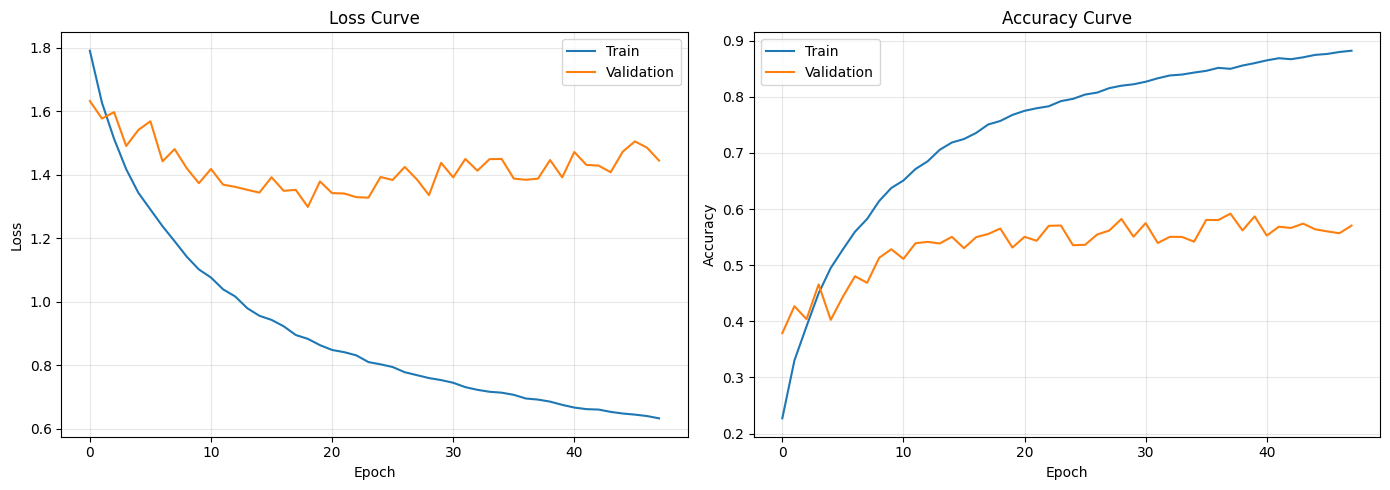

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'emotion_training_curves.png'), dpi=150)
plt.show()

## 5. 测试集评估

              precision    recall  f1-score   support

       happy       0.25      0.17      0.21      1128
       angry       0.57      0.61      0.59      1131
         sad       0.52      0.72      0.60      1124
     neutral       0.58      0.45      0.51      1149
        fear       0.26      0.68      0.37       108
    surprise       0.65      0.63      0.64      1139

    accuracy                           0.52      5779
   macro avg       0.47      0.54      0.49      5779
weighted avg       0.51      0.52      0.51      5779



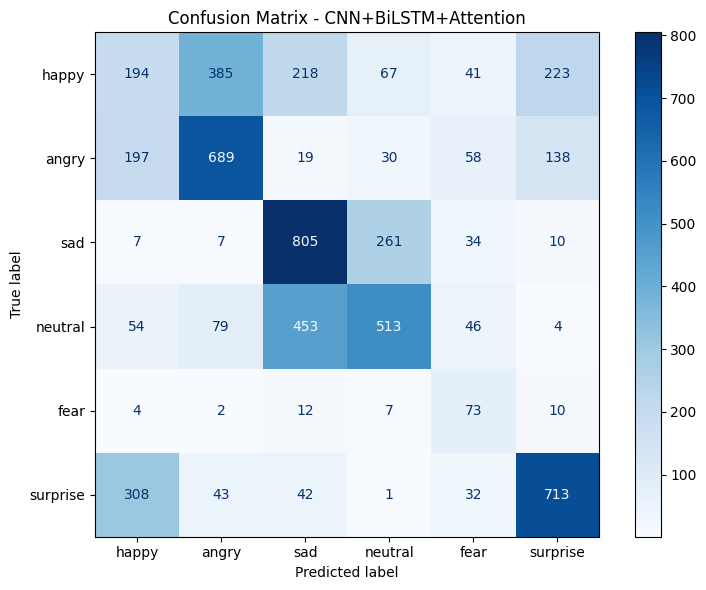

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from utils.audio_utils import EMOTION_LABELS

model.load_state_dict(best_state)
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for feats, labels in test_loader:
        feats = feats.to(device)
        preds = model(feats).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

print(classification_report(all_labels_list, all_preds, target_names=EMOTION_LABELS, zero_division=0))

cm = confusion_matrix(all_labels_list, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - CNN+BiLSTM+Attention')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'confusion_matrix.png'), dpi=150)
plt.show()